## Testing Methods in the `DWITOOLS` Module

This Jupyter Notebook serves as a platform to rigorously test the various methods included in the Python module `DWITOOLS`.

This module is particularly valuable for researchers working with diffusion weighted images: removing
volumes from a DWI series while keeping the bvec/bval files consistent, extracting the B0 volumes,
deriving scalar maps from the diffusion tensor eigenvalues, and representing and visualizing the
acquisition scheme (single-shell, multi-shell/HARDI or cartesian/DSI), including the simulation of
synthetic schemes.

The tests are organized into the following sections for clarity and ease of navigation:

### Table of Contents

---

* 🔷 1. [`Methods to Work with DWI Images`](#dwi-images). Methods to work with diffusion weighted images and their derived maps
    * 🔸 1.1. [`delete_dwi_volumes`](#dwi-delete_dwi_volumes). Remove specific volumes, selected by index or by b-value, from a DWI image and update its bvec/bval files
    * 🔸 1.2. [`get_b0s`](#dwi-get_b0s). Extract the B0 volumes from a DWI image and save them as a separate NIfTI file
    * 🔸 1.3. [`maps_from_tensor_eigenvalues`](#dwi-maps_from_tensor_eigenvalues). Compute scalar maps derived from the diffusion tensor eigenvalues

* 🔷 2. [`DiffusionScheme Class`](#diffscheme-class). Class to represent, detect and visualize diffusion acquisition schemes
    * 🔸 2.1. [`from_bvec_bval_files`](#diffscheme-from_bvec_bval_files). Create a DiffusionScheme object from bvec and bval files
    * 🔸 2.2. [`from_bvec_bval_arrays`](#diffscheme-from_bvec_bval_arrays). Create a DiffusionScheme object from bvec and bval arrays
    * 🔸 2.3. [`from_bmatrix_file`](#diffscheme-from_bmatrix_file). Create a DiffusionScheme object from a b-matrix file
    * 🔸 2.4. [`from_bmatrix_array`](#diffscheme-from_bmatrix_array). Create a DiffusionScheme object from a b-matrix array with shape (N, 6): [Bxx, Byy, Bzz, Bxy, Bxz, Byz]
    * 🔸 2.5. [`simulate_dwi_acq_scheme`](#diffscheme-simulate_dwi_acq_scheme). Simulate a shelled (single/multi-shell HARDI) or cartesian (DSI) acquisition scheme
    * 🔸 2.6. [`plot`](#diffscheme-plot). Plot the diffusion acquisition scheme in 3D with customizable rendering options

---

---
## <a id="dwi-images"></a>1. Methods to Work with DWI Images
Methods to work with diffusion weighted images and their derived maps.

### 1.1 `delete_dwi_volumes`
<a id="dwi-delete_dwi_volumes"></a>

Remove specific volumes, selected by index or by b-value, from a DWI image and update its bvec/bval files.

In [ ]:
########################### Testing delete_dwi_volumes ###########################
import clabtoolkit.dwitools as cltdwi
import nibabel as nib
import numpy as np
import os

out_dir = "/tmp/dwitools_examples"
os.makedirs(out_dir, exist_ok=True)

# Simulated multi-shell DWI: B0s interleaved, two shells (b=1000 and b=2000) and two trailing B0s.
# Each volume is filled with its own index so we can track which volumes are kept.
bvals = np.array([0, 1000, 1000, 1000, 0, 2000, 2000, 2000, 1000, 2000, 0, 0])
nvols = len(bvals)
rng = np.random.default_rng(0)
bvecs = rng.normal(size=(3, nvols))
bvecs /= np.linalg.norm(bvecs, axis=0)
bvecs[:, bvals == 0] = 0

dwi_file = os.path.join(out_dir, "sub-01_dwi.nii.gz")
data = np.broadcast_to(np.arange(nvols, dtype=np.float32), (16, 16, 8, nvols)).copy()
nib.save(nib.Nifti1Image(data, np.diag([2.0, 2.0, 2.0, 1.0])), dwi_file)
np.savetxt(os.path.join(out_dir, "sub-01_dwi.bvec"), bvecs, fmt="%.6f")       # FSL format: 3 x N
np.savetxt(os.path.join(out_dir, "sub-01_dwi.bval"), bvals[None, :], fmt="%d")  # FSL format: 1 x N

def kept(nifti_file):
    """Original indexes of the volumes stored in a DWI file."""
    return nib.load(nifti_file).get_fdata()[0, 0, 0, :].astype(int).tolist()

print(f"Original b-values: {bvals.tolist()}")
print(" ")

print("Test 1: Without volumes or b-values to delete, the trailing B0 volumes are removed...")
print("NOTE: The bvec and bval files are taken from the same folder and name as the DWI image.")
out_img, out_bvec, out_bval, removed = cltdwi.delete_dwi_volumes(
    dwi_file, out_image=os.path.join(out_dir, "sub-01_desc-notrailing_dwi.nii.gz")
)
print(f"  Removed volumes: {removed.tolist()}")
print(f"  Kept volumes   : {kept(out_img)}")
print(f"  New b-values   : {open(out_bval).read().split()}")
print("-------------------------------")
print(" ")

print("Test 2: Removing volumes by index (integers and range strings can be mixed)...")
out_img, out_bvec, out_bval, removed = cltdwi.delete_dwi_volumes(
    dwi_file, out_image=os.path.join(out_dir, "sub-01_desc-subset_dwi.nii.gz"), vols_to_delete=[1, "5-6"]
)
print(f"  Removed volumes: {removed.tolist()}")
print(f"  New b-values   : {open(out_bval).read().split()}")
print(f"  bvec shape     : {np.loadtxt(out_bvec).shape} (3 x kept volumes)")
print("-------------------------------")
print(" ")

print("Test 3: Removing a whole shell by b-value, and by a condition on the b-values...")
out_img, _, out_bval, removed = cltdwi.delete_dwi_volumes(
    dwi_file, out_image=os.path.join(out_dir, "sub-01_desc-b1000_dwi.nii.gz"), bvals_to_delete=[2000]
)
print(f"  bvals_to_delete=[2000]                 -> removed {removed.tolist()}, b-values {open(out_bval).read().split()}")
out_img, _, out_bval, removed = cltdwi.delete_dwi_volumes(
    dwi_file, out_image=os.path.join(out_dir, "sub-01_desc-lowb_dwi.nii.gz"), bvals_to_delete=["500 < bvals < 1500"]
)
print(f"  bvals_to_delete=['500 < bvals < 1500'] -> removed {removed.tolist()}, b-values {open(out_bval).read().split()}")
print("-------------------------------")
print(" ")

print("Test 4: Requesting volumes that do not exist...")
try:
    cltdwi.delete_dwi_volumes(dwi_file, out_image=os.path.join(out_dir, "bad_dwi.nii.gz"), vols_to_delete=[3, 40])
except ValueError as e:
    print(f"  ValueError: {e}")
print("-------------------------------")


### 1.2 `get_b0s`
<a id="dwi-get_b0s"></a>

Extract the B0 volumes from a DWI image and save them as a separate NIfTI file.

In [ ]:
########################### Testing get_b0s ###########################
import clabtoolkit.dwitools as cltdwi
import nibabel as nib
import numpy as np
import os

out_dir = "/tmp/dwitools_examples"
os.makedirs(out_dir, exist_ok=True)

# Simulated multi-shell DWI: B0s interleaved, two shells (b=1000 and b=2000) and two trailing B0s.
# Each volume is filled with its own index so we can track which volumes are kept.
bvals = np.array([0, 1000, 1000, 1000, 0, 2000, 2000, 2000, 1000, 2000, 0, 0])
nvols = len(bvals)
rng = np.random.default_rng(0)
bvecs = rng.normal(size=(3, nvols))
bvecs /= np.linalg.norm(bvecs, axis=0)
bvecs[:, bvals == 0] = 0

dwi_file = os.path.join(out_dir, "sub-01_dwi.nii.gz")
data = np.broadcast_to(np.arange(nvols, dtype=np.float32), (16, 16, 8, nvols)).copy()
nib.save(nib.Nifti1Image(data, np.diag([2.0, 2.0, 2.0, 1.0])), dwi_file)
np.savetxt(os.path.join(out_dir, "sub-01_dwi.bvec"), bvecs, fmt="%.6f")       # FSL format: 3 x N
np.savetxt(os.path.join(out_dir, "sub-01_dwi.bval"), bvals[None, :], fmt="%d")  # FSL format: 1 x N

def kept(nifti_file):
    """Original indexes of the volumes stored in a DWI file."""
    return nib.load(nifti_file).get_fdata()[0, 0, 0, :].astype(int).tolist()

print(f"Original b-values: {bvals.tolist()}")
print(" ")

print("Test 1: Extracting the B0 volumes (the bval file is found next to the DWI image)...")
b0_file, b0_vols = cltdwi.get_b0s(dwi_file, os.path.join(out_dir, "sub-01_desc-b0_dwi.nii.gz"))
print(f"  B0 volumes: {b0_vols.tolist()}, output shape: {nib.load(b0_file).shape}")
print("-------------------------------")
print(" ")

print("Test 2: Low b-value volumes (b=5) are only counted as B0s when bval_thresh is raised (e.g. to 50)...")
bvals_lowb = np.where(bvals == 0, 5, bvals)
lowb_bval = os.path.join(out_dir, "sub-01_acq-lowb_dwi.bval")
np.savetxt(lowb_bval, bvals_lowb[:, None], fmt="%d")       # b-values stored as a single column
try:
    cltdwi.get_b0s(dwi_file, os.path.join(out_dir, "sub-01_desc-b0default_dwi.nii.gz"), bval_file=lowb_bval)
except ValueError as e:
    print(f"  bval_thresh=0 : ValueError: {e}")
_, b0_thresh = cltdwi.get_b0s(dwi_file, os.path.join(out_dir, "sub-01_desc-b0thresh_dwi.nii.gz"), bval_file=lowb_bval,
                              bval_thresh=50)
print(f"  bval_thresh=50: {b0_thresh.tolist()}")
print("-------------------------------")
print(" ")

print("Test 3: Without an output name the B0s are saved next to the DWI image. Averaging them gives a reference image...")
b0_default_file, b0_vols = cltdwi.get_b0s(dwi_file)
print(f"  Output: {os.path.basename(b0_default_file)}")
b0_mean = nib.load(b0_default_file).get_fdata().mean(axis=3)
print(f"  Mean B0 shape: {b0_mean.shape}, value: {b0_mean[0, 0, 0]} (mean of the indexes {b0_vols.tolist()})")
print("-------------------------------")


### 1.3 `maps_from_tensor_eigenvalues`
<a id="dwi-maps_from_tensor_eigenvalues"></a>

Compute scalar maps derived from the diffusion tensor eigenvalues.

In [ ]:
########################### Testing maps_from_tensor_eigenvalues ###########################
import clabtoolkit.dwitools as cltdwi
import nibabel as nib
import numpy as np
import pandas as pd
import os

out_dir = "/tmp/dwitools_examples/dti"
os.makedirs(out_dir, exist_ok=True)

# Eigenvalue image with three voxels representing typical tensor shapes (mm2/s)
eig = np.zeros((3, 1, 1, 3))
eig[0, 0, 0] = [1.0e-3, 1.0e-3, 1.0e-3]   # Isotropic (e.g. CSF-like)
eig[1, 0, 0] = [1.7e-3, 0.3e-3, 0.3e-3]   # Prolate (single fiber bundle)
eig[2, 0, 0] = [1.2e-3, 1.2e-3, 0.2e-3]   # Oblate (crossing fibers in a plane)
shapes = ["isotropic", "prolate", "oblate"]
eig_file = os.path.join(out_dir, "sub-01_desc-eigvals_dwi.nii.gz")
nib.save(nib.Nifti1Image(eig, np.eye(4)), eig_file)

print("Test 1: Computing FA, MD, AD and RD from a 4D eigenvalue image...")
maps = cltdwi.maps_from_tensor_eigenvalues(eig_file, os.path.join(out_dir, "sub-01_desc-DTI"),
                                           dtmaps=["FA", "MD", "AD", "RD"], overwrite=True)
for tag, path in maps.items():
    print(f"  {tag}: {np.round(nib.load(path).get_fdata().ravel(), 5)}  ->  {os.path.basename(path)}")
print("-------------------------------")
print(" ")

print("Test 2: Computing all the maps from three separate eigenvalue files (L1, L2, L3)...")
l_files = []
for i in range(3):
    f = os.path.join(out_dir, f"sub-01_desc-L{i + 1}_dwi.nii.gz")
    nib.save(nib.Nifti1Image(eig[..., i], np.eye(4)), f)
    l_files.append(f)
maps_all = cltdwi.maps_from_tensor_eigenvalues(l_files, os.path.join(out_dir, "sub-01_desc-DTIall"), overwrite=True)
table = pd.DataFrame({tag: nib.load(p).get_fdata().ravel() for tag, p in maps_all.items()}, index=shapes)
print(table.round(4).T)
print("-------------------------------")
print(" ")

print("Test 3: Without overwrite, existing maps are not recomputed (the paths are returned directly)...")
mtime = os.path.getmtime(maps["FA"])
maps_again = cltdwi.maps_from_tensor_eigenvalues(eig_file, os.path.join(out_dir, "sub-01_desc-DTI"), dtmaps=["FA"])
print(f"  Same file: {maps_again['FA'] == maps['FA']}, untouched: {os.path.getmtime(maps_again['FA']) == mtime}")
print("-------------------------------")
print(" ")

print("Test 4: Supplying only two eigenvalue files...")
try:
    cltdwi.maps_from_tensor_eigenvalues(l_files[:2], os.path.join(out_dir, "bad"))
except ValueError as e:
    print(f"  ValueError: {e}")
print("-------------------------------")


---
## <a id="diffscheme-class"></a>2. DiffusionScheme Class
Class to represent, detect and visualize diffusion acquisition schemes.

### 2.1 `from_bvec_bval_files`
<a id="diffscheme-from_bvec_bval_files"></a>

Create a DiffusionScheme object from bvec and bval files.

In [ ]:
########################### Testing from_bvec_bval_files ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

def sphere_dirs(n):
    """n directions evenly distributed on the half sphere (Fibonacci lattice)."""
    i = np.arange(n) + 0.5
    z = 1 - i / n
    phi = np.pi * (1 + 5**0.5) * i
    r = np.sqrt(1 - z**2)
    return np.c_[r * np.cos(phi), r * np.sin(phi), z]

def shelled_scheme(shells, n_b0=6):
    """bvecs (3 x N) and bvals (N,) for a shelled acquisition: {b-value: number of directions}."""
    g = [np.zeros((n_b0, 3))] + [sphere_dirs(n) for n in shells.values()]
    b = [np.zeros(n_b0)] + [np.full(n, bval) for bval, n in shells.items()]
    return np.vstack(g).T, np.concatenate(b)

def dsi_scheme(bmax=4000, radius=4):
    """Cartesian (DSI) q-space grid: every grid point inside a sphere of the given radius."""
    grid = np.array([(i, j, k) for i in range(-radius, radius + 1) for j in range(-radius, radius + 1)
                     for k in range(0, radius + 1) if 0 < i * i + j * j + k * k <= radius**2])
    q = np.linalg.norm(grid, axis=1)
    return (grid / q[:, None]).T, bmax * (q / radius) ** 2

def describe(scheme):
    shells = np.unique(np.round(scheme.bvals[scheme.bvals > 50], -2)).astype(int)
    print(f"  Volumes: {len(scheme.bvals)}, B0s: {(scheme.bvals <= 50).sum()}, "
          f"shells: {shells.tolist() if len(shells) <= 8 else f'{len(shells)} distinct b-values'}, "
          f"scheme: {scheme.scheme_type}")

print("Test 1: Loading a single-shell scheme (6 B0s + 64 directions at b=1000) from FSL files...")
bvecs, bvals = shelled_scheme({1000: 64})
np.savetxt(os.path.join(out_dir, "single_shell.bvec"), bvecs, fmt="%.6f")
np.savetxt(os.path.join(out_dir, "single_shell.bval"), bvals[None, :], fmt="%d")
scheme = cltdwi.DiffusionScheme.from_bvec_bval_files(os.path.join(out_dir, "single_shell.bvec"),
                                                     os.path.join(out_dir, "single_shell.bval"))
describe(scheme)
print(f"  Gradients stored as (N, 3): {scheme.gradients.shape}")
print("-------------------------------")
print(" ")

print("Test 2: Loading a multi-shell (HARDI) scheme...")
bvecs, bvals = shelled_scheme({1000: 30, 2000: 60, 3000: 90})
np.savetxt(os.path.join(out_dir, "multi_shell.bvec"), bvecs, fmt="%.6f")
np.savetxt(os.path.join(out_dir, "multi_shell.bval"), bvals[None, :], fmt="%d")
describe(cltdwi.DiffusionScheme.from_bvec_bval_files(os.path.join(out_dir, "multi_shell.bvec"),
                                                     os.path.join(out_dir, "multi_shell.bval")))
print("-------------------------------")
print(" ")

print("Test 3: Gradients stored as N x 3 (one direction per row) are also accepted...")
np.savetxt(os.path.join(out_dir, "multi_shell_rows.bvec"), bvecs.T, fmt="%.6f")
scheme_rows = cltdwi.DiffusionScheme.from_bvec_bval_files(os.path.join(out_dir, "multi_shell_rows.bvec"),
                                                          os.path.join(out_dir, "multi_shell.bval"))

# Plot the gradients stored as N x 3 to verify their arrangement
# Plot the gradients stored as 3 x N to verify their arrangement
scheme_rows.plot(save_path=os.path.join(out_dir, "multi_shell_gradients.png"))

# Display the saved gradient plot
from IPython.display import Image
Image(os.path.join(out_dir, "multi_shell_gradients.png"))

scheme_cols = cltdwi.DiffusionScheme.from_bvec_bval_files(os.path.join(out_dir, "multi_shell.bvec"),
                                                        os.path.join(out_dir, "multi_shell.bval"))
scheme_cols.plot()
print(f"  Gradients shape: {scheme_rows.gradients.shape}, same as the 3 x N file: {np.allclose(scheme_rows.gradients, scheme_cols.gradients)}")


print("-------------------------------")


### 2.2 `from_bvec_bval_arrays`
<a id="diffscheme-from_bvec_bval_arrays"></a>

Create a DiffusionScheme object from bvec and bval arrays.

In [ ]:
########################### Testing from_bvec_bval_arrays ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

def sphere_dirs(n):
    """n directions evenly distributed on the half sphere (Fibonacci lattice)."""
    i = np.arange(n) + 0.5
    z = 1 - i / n
    phi = np.pi * (1 + 5**0.5) * i
    r = np.sqrt(1 - z**2)
    return np.c_[r * np.cos(phi), r * np.sin(phi), z]

def shelled_scheme(shells, n_b0=6):
    """bvecs (3 x N) and bvals (N,) for a shelled acquisition: {b-value: number of directions}."""
    g = [np.zeros((n_b0, 3))] + [sphere_dirs(n) for n in shells.values()]
    b = [np.zeros(n_b0)] + [np.full(n, bval) for bval, n in shells.items()]
    return np.vstack(g).T, np.concatenate(b)

def dsi_scheme(bmax=4000, radius=4):
    """Cartesian (DSI) q-space grid: every grid point inside a sphere of the given radius."""
    grid = np.array([(i, j, k) for i in range(-radius, radius + 1) for j in range(-radius, radius + 1)
                     for k in range(0, radius + 1) if 0 < i * i + j * j + k * k <= radius**2])
    q = np.linalg.norm(grid, axis=1)
    return (grid / q[:, None]).T, bmax * (q / radius) ** 2

def describe(scheme):
    shells = np.unique(np.round(scheme.bvals[scheme.bvals > 50], -2)).astype(int)
    print(f"  Volumes: {len(scheme.bvals)}, B0s: {(scheme.bvals <= 50).sum()}, "
          f"shells: {shells.tolist() if len(shells) <= 8 else f'{len(shells)} distinct b-values'}, "
          f"scheme: {scheme.scheme_type}")

print("Test 1: Creating a multi-shell scheme from arrays...")
bvecs, bvals = shelled_scheme({0:2, 1000: 32, 2500: 64})
describe(cltdwi.DiffusionScheme.from_bvec_bval_arrays(bvecs, bvals))
print("-------------------------------")
print(" ")

print("Test 2: A cartesian q-space grid (DSI) is detected as 'cartesian'...")
bvecs_dsi, bvals_dsi = dsi_scheme()
describe(cltdwi.DiffusionScheme.from_bvec_bval_arrays(bvecs_dsi, bvals_dsi))
print("-------------------------------")
print(" ")

print("Test 3: An acquisition with only B0 volumes...")
describe(cltdwi.DiffusionScheme.from_bvec_bval_arrays(np.zeros((3, 5)), np.zeros(5)))
print("-------------------------------")


### 2.3 `from_bmatrix_file`
<a id="diffscheme-from_bmatrix_file"></a>

Create a DiffusionScheme object from a b-matrix file.

In [ ]:
########################### Testing from_bmatrix_file ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

def sphere_dirs(n):
    """n directions evenly distributed on the half sphere (Fibonacci lattice)."""
    i = np.arange(n) + 0.5
    z = 1 - i / n
    phi = np.pi * (1 + 5**0.5) * i
    r = np.sqrt(1 - z**2)
    return np.c_[r * np.cos(phi), r * np.sin(phi), z]

def shelled_scheme(shells, n_b0=6):
    """bvecs (3 x N) and bvals (N,) for a shelled acquisition: {b-value: number of directions}."""
    g = [np.zeros((n_b0, 3))] + [sphere_dirs(n) for n in shells.values()]
    b = [np.zeros(n_b0)] + [np.full(n, bval) for bval, n in shells.items()]
    return np.vstack(g).T, np.concatenate(b)

def dsi_scheme(bmax=4000, radius=4):
    """Cartesian (DSI) q-space grid: every grid point inside a sphere of the given radius."""
    grid = np.array([(i, j, k) for i in range(-radius, radius + 1) for j in range(-radius, radius + 1)
                     for k in range(0, radius + 1) if 0 < i * i + j * j + k * k <= radius**2])
    q = np.linalg.norm(grid, axis=1)
    return (grid / q[:, None]).T, bmax * (q / radius) ** 2

def describe(scheme):
    shells = np.unique(np.round(scheme.bvals[scheme.bvals > 50], -2)).astype(int)
    print(f"  Volumes: {len(scheme.bvals)}, B0s: {(scheme.bvals <= 50).sum()}, "
          f"shells: {shells.tolist() if len(shells) <= 8 else f'{len(shells)} distinct b-values'}, "
          f"scheme: {scheme.scheme_type}")

def to_bmatrix(bvecs, bvals):
    """b-matrix rows [Bxx, Byy, Bzz, Bxy, Bxz, Byz] from bvecs (3 x N) and bvals (N,)."""
    gx, gy, gz = bvecs
    return np.c_[bvals * gx * gx, bvals * gy * gy, bvals * gz * gz,
                 bvals * gx * gy, bvals * gx * gz, bvals * gy * gz]

print("Test 1: Loading a single-shell scheme stored as a b-matrix file (N x 6)...")
bvecs, bvals = shelled_scheme({1000: 64})
bmat_file = os.path.join(out_dir, "single_shell.bmat")
np.savetxt(bmat_file, to_bmatrix(bvecs, bvals), fmt="%.6f")
scheme = cltdwi.DiffusionScheme.from_bmatrix_file(bmat_file)
describe(scheme)
print(f"  b-values recovered from the trace of the b-matrix: {np.allclose(scheme.bvals, bvals, atol=1e-2)}")
print("-------------------------------")
print(" ")

print("Test 2: Loading a multi-shell b-matrix file...")
bvecs, bvals = shelled_scheme({1000: 30, 2000: 60})
np.savetxt(os.path.join(out_dir, "multi_shell.bmat"), to_bmatrix(bvecs, bvals), fmt="%.6f")
describe(cltdwi.DiffusionScheme.from_bmatrix_file(os.path.join(out_dir, "multi_shell.bmat")))
print("-------------------------------")


### 2.4 `from_bmatrix_array`
<a id="diffscheme-from_bmatrix_array"></a>

Create a DiffusionScheme object from a b-matrix array with shape (N, 6): [Bxx, Byy, Bzz, Bxy, Bxz, Byz].

In [ ]:
########################### Testing from_bmatrix_array ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

def sphere_dirs(n):
    """n directions evenly distributed on the half sphere (Fibonacci lattice)."""
    i = np.arange(n) + 0.5
    z = 1 - i / n
    phi = np.pi * (1 + 5**0.5) * i
    r = np.sqrt(1 - z**2)
    return np.c_[r * np.cos(phi), r * np.sin(phi), z]

def shelled_scheme(shells, n_b0=6):
    """bvecs (3 x N) and bvals (N,) for a shelled acquisition: {b-value: number of directions}."""
    g = [np.zeros((n_b0, 3))] + [sphere_dirs(n) for n in shells.values()]
    b = [np.zeros(n_b0)] + [np.full(n, bval) for bval, n in shells.items()]
    return np.vstack(g).T, np.concatenate(b)

def dsi_scheme(bmax=4000, radius=4):
    """Cartesian (DSI) q-space grid: every grid point inside a sphere of the given radius."""
    grid = np.array([(i, j, k) for i in range(-radius, radius + 1) for j in range(-radius, radius + 1)
                     for k in range(0, radius + 1) if 0 < i * i + j * j + k * k <= radius**2])
    q = np.linalg.norm(grid, axis=1)
    return (grid / q[:, None]).T, bmax * (q / radius) ** 2

def describe(scheme):
    shells = np.unique(np.round(scheme.bvals[scheme.bvals > 50], -2)).astype(int)
    print(f"  Volumes: {len(scheme.bvals)}, B0s: {(scheme.bvals <= 50).sum()}, "
          f"shells: {shells.tolist() if len(shells) <= 8 else f'{len(shells)} distinct b-values'}, "
          f"scheme: {scheme.scheme_type}")

def to_bmatrix(bvecs, bvals):
    """b-matrix rows [Bxx, Byy, Bzz, Bxy, Bxz, Byz] from bvecs (3 x N) and bvals (N,)."""
    gx, gy, gz = bvecs
    return np.c_[bvals * gx * gx, bvals * gy * gy, bvals * gz * gz,
                 bvals * gx * gy, bvals * gx * gz, bvals * gy * gz]

print("Test 1: b-matrix of five gradient directions at b=1000 (the last one has a negative component)...")
dirs = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0] / np.sqrt(2), [1, -1, 0] / np.sqrt(2)]).T
scheme = cltdwi.DiffusionScheme.from_bmatrix_array(to_bmatrix(dirs, np.full(5, 1000.0)))
print(f"  b-values: {scheme.bvals}")
print(f"  Gradients:\n{np.round(scheme.gradients, 4)}")
print("-------------------------------")
print(" ")

print("Test 2: Rows of zeros correspond to B0 volumes (b=0 and a zero gradient)...")
bmat = np.vstack([np.zeros((2, 6)), to_bmatrix(dirs, np.full(5, 2000.0))])
scheme = cltdwi.DiffusionScheme.from_bmatrix_array(bmat)
print(f"  b-values: {scheme.bvals}, first gradient: {scheme.gradients[0]}")
print("-------------------------------")
print(" ")

print("Test 3: A DSI scheme given as a b-matrix is detected as cartesian...")
bvecs_dsi, bvals_dsi = dsi_scheme()
describe(cltdwi.DiffusionScheme.from_bmatrix_array(to_bmatrix(bvecs_dsi, bvals_dsi)))
print("-------------------------------")


### 2.5 `simulate_dwi_acq_scheme`
<a id="diffscheme-simulate_dwi_acq_scheme"></a>

Simulate a shelled (single/multi-shell HARDI) or cartesian (DSI) acquisition scheme. Shell directions are spread over the half sphere with an antipodally symmetric electrostatic repulsion, and the DSI scheme samples every q-space grid point inside a sphere of the given radius. Both schemes start with `n_b0s` B0 volumes.

In [ ]:
########################### Testing simulate_dwi_acq_scheme ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

def describe(scheme):
    shells = np.unique(np.round(scheme.bvals[scheme.bvals > 50], -2)).astype(int)
    print(f"  Volumes: {len(scheme.bvals)}, B0s: {(scheme.bvals <= 50).sum()}, "
        f"shells: {shells.tolist() if len(shells) <= 8 else f'{len(shells)} distinct b-values'}, "
        f"scheme: {scheme.scheme_type}")

def min_angle(dirs):
    """Smallest angle (degrees) between two directions, treating opposite directions as equal."""
    c = np.abs(dirs @ dirs.T)
    np.fill_diagonal(c, 0)
    return np.degrees(np.arccos(np.clip(c.max(), -1, 1)))

print("Test 1: Simulating a multi-shell (HARDI) scheme with 8 B0s...")
scheme = cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("shelled", shells={1000: 32, 2000: 64, 3000: 96}, n_b0s=8)
describe(scheme)
for bval in (1000, 2000, 3000):
    dirs = scheme.gradients[scheme.bvals == bval]
    print(f"  b={bval}: {len(dirs)} unit directions: {np.allclose(np.linalg.norm(dirs, axis=1), 1)}, "
        f"minimum angle: {min_angle(dirs):.1f} deg")
print("-------------------------------")
scheme.plot()
print(" ")

print("Test 2: Default shelled scheme ({1000: 30, 2000: 60}) and the 'shell' alias...")
describe(cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("shell"))
print("-------------------------------")
print(" ")

print("Test 3: Simulating a cartesian (DSI) scheme; n_b0s also applies here...")
for radius, n_b0s in [(4, 1), (5, 3)]:
    scheme_dsi = cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("dsi", bmax=4000, radius=radius, n_b0s=n_b0s)
    print(f"  radius={radius}, n_b0s={n_b0s}:")
    describe(scheme_dsi)
    print(f"    first b-values: {np.round(scheme_dsi.bvals[:n_b0s + 2]).astype(int).tolist()}, max b-value: {scheme_dsi.bvals.max():.0f}")
print("-------------------------------")

scheme_dsi.plot()
print(" ")

print("Test 4: Saving a simulated scheme as FSL bvec/bval files and loading it back...")
scheme = cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("shelled", shells={1000: 64}, n_b0s=6)
np.savetxt(os.path.join(out_dir, "sim_shell.bvec"), scheme.gradients.T, fmt="%.6f")
np.savetxt(os.path.join(out_dir, "sim_shell.bval"), scheme.bvals[None, :], fmt="%d")
loaded = cltdwi.DiffusionScheme.from_bvec_bval_files(os.path.join(out_dir, "sim_shell.bvec"),
                                                    os.path.join(out_dir, "sim_shell.bval"))
print(f"  Same gradients: {np.allclose(loaded.gradients, scheme.gradients, atol=1e-5)}, "
    f"same b-values: {np.array_equal(loaded.bvals, scheme.bvals)}, detected scheme: {loaded.scheme_type}")
print("-------------------------------")
print(" ")

print("Test 5: Invalid inputs...")
for kwargs in [{"scheme_type": "spiral"}, {"scheme_type": "shelled", "n_b0s": -1}, {"scheme_type": "dsi", "radius": 0}]:
    try:
        cltdwi.DiffusionScheme.simulate_dwi_acq_scheme(**kwargs)
    except ValueError as e:
        print(f"  {kwargs} -> ValueError: {e}")
print("-------------------------------")


### 2.6 `plot`
<a id="diffscheme-plot"></a>

Plot the diffusion acquisition scheme in 3D with customizable rendering options.

Test 1: Saving a single-shell scheme as a PNG image (each direction and its opposite)...
Figure saved to: /tmp/dwitools_examples/schemes/single_shell.png


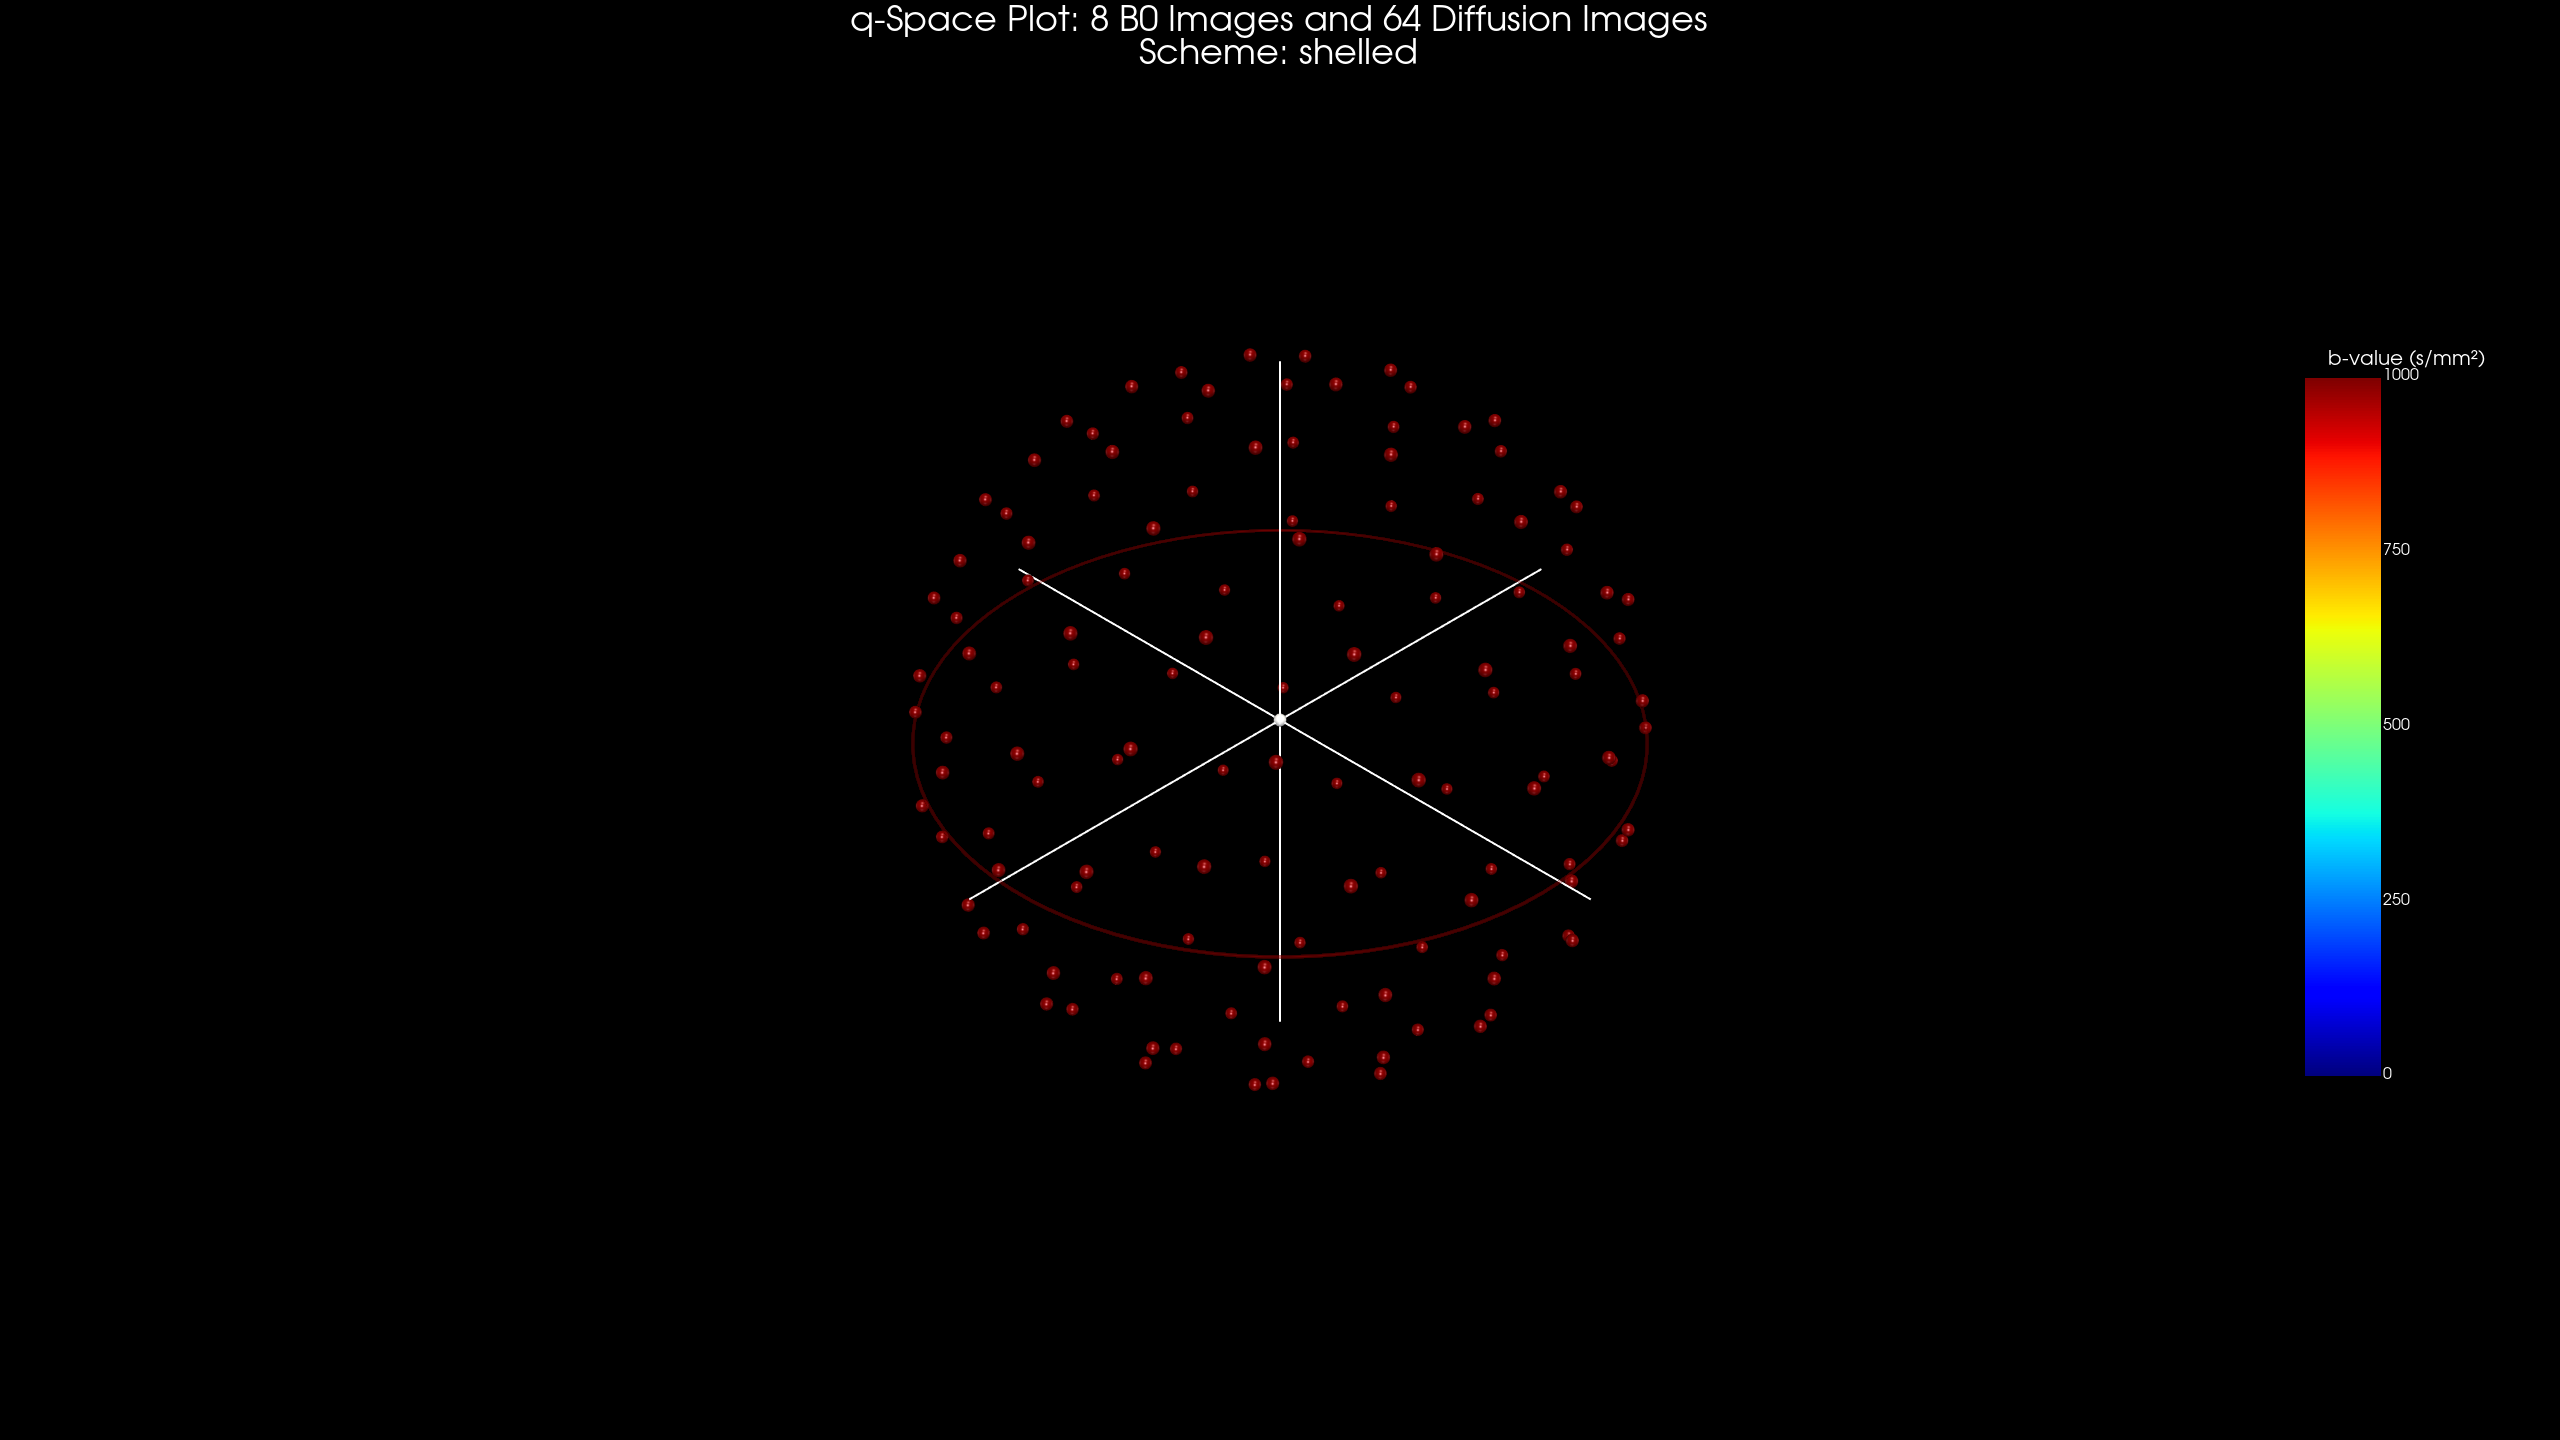

-------------------------------
 
Test 2: Saving a multi-shell scheme with another colormap, without the opposite directions...
Figure saved to: /tmp/dwitools_examples/schemes/multi_shell.png


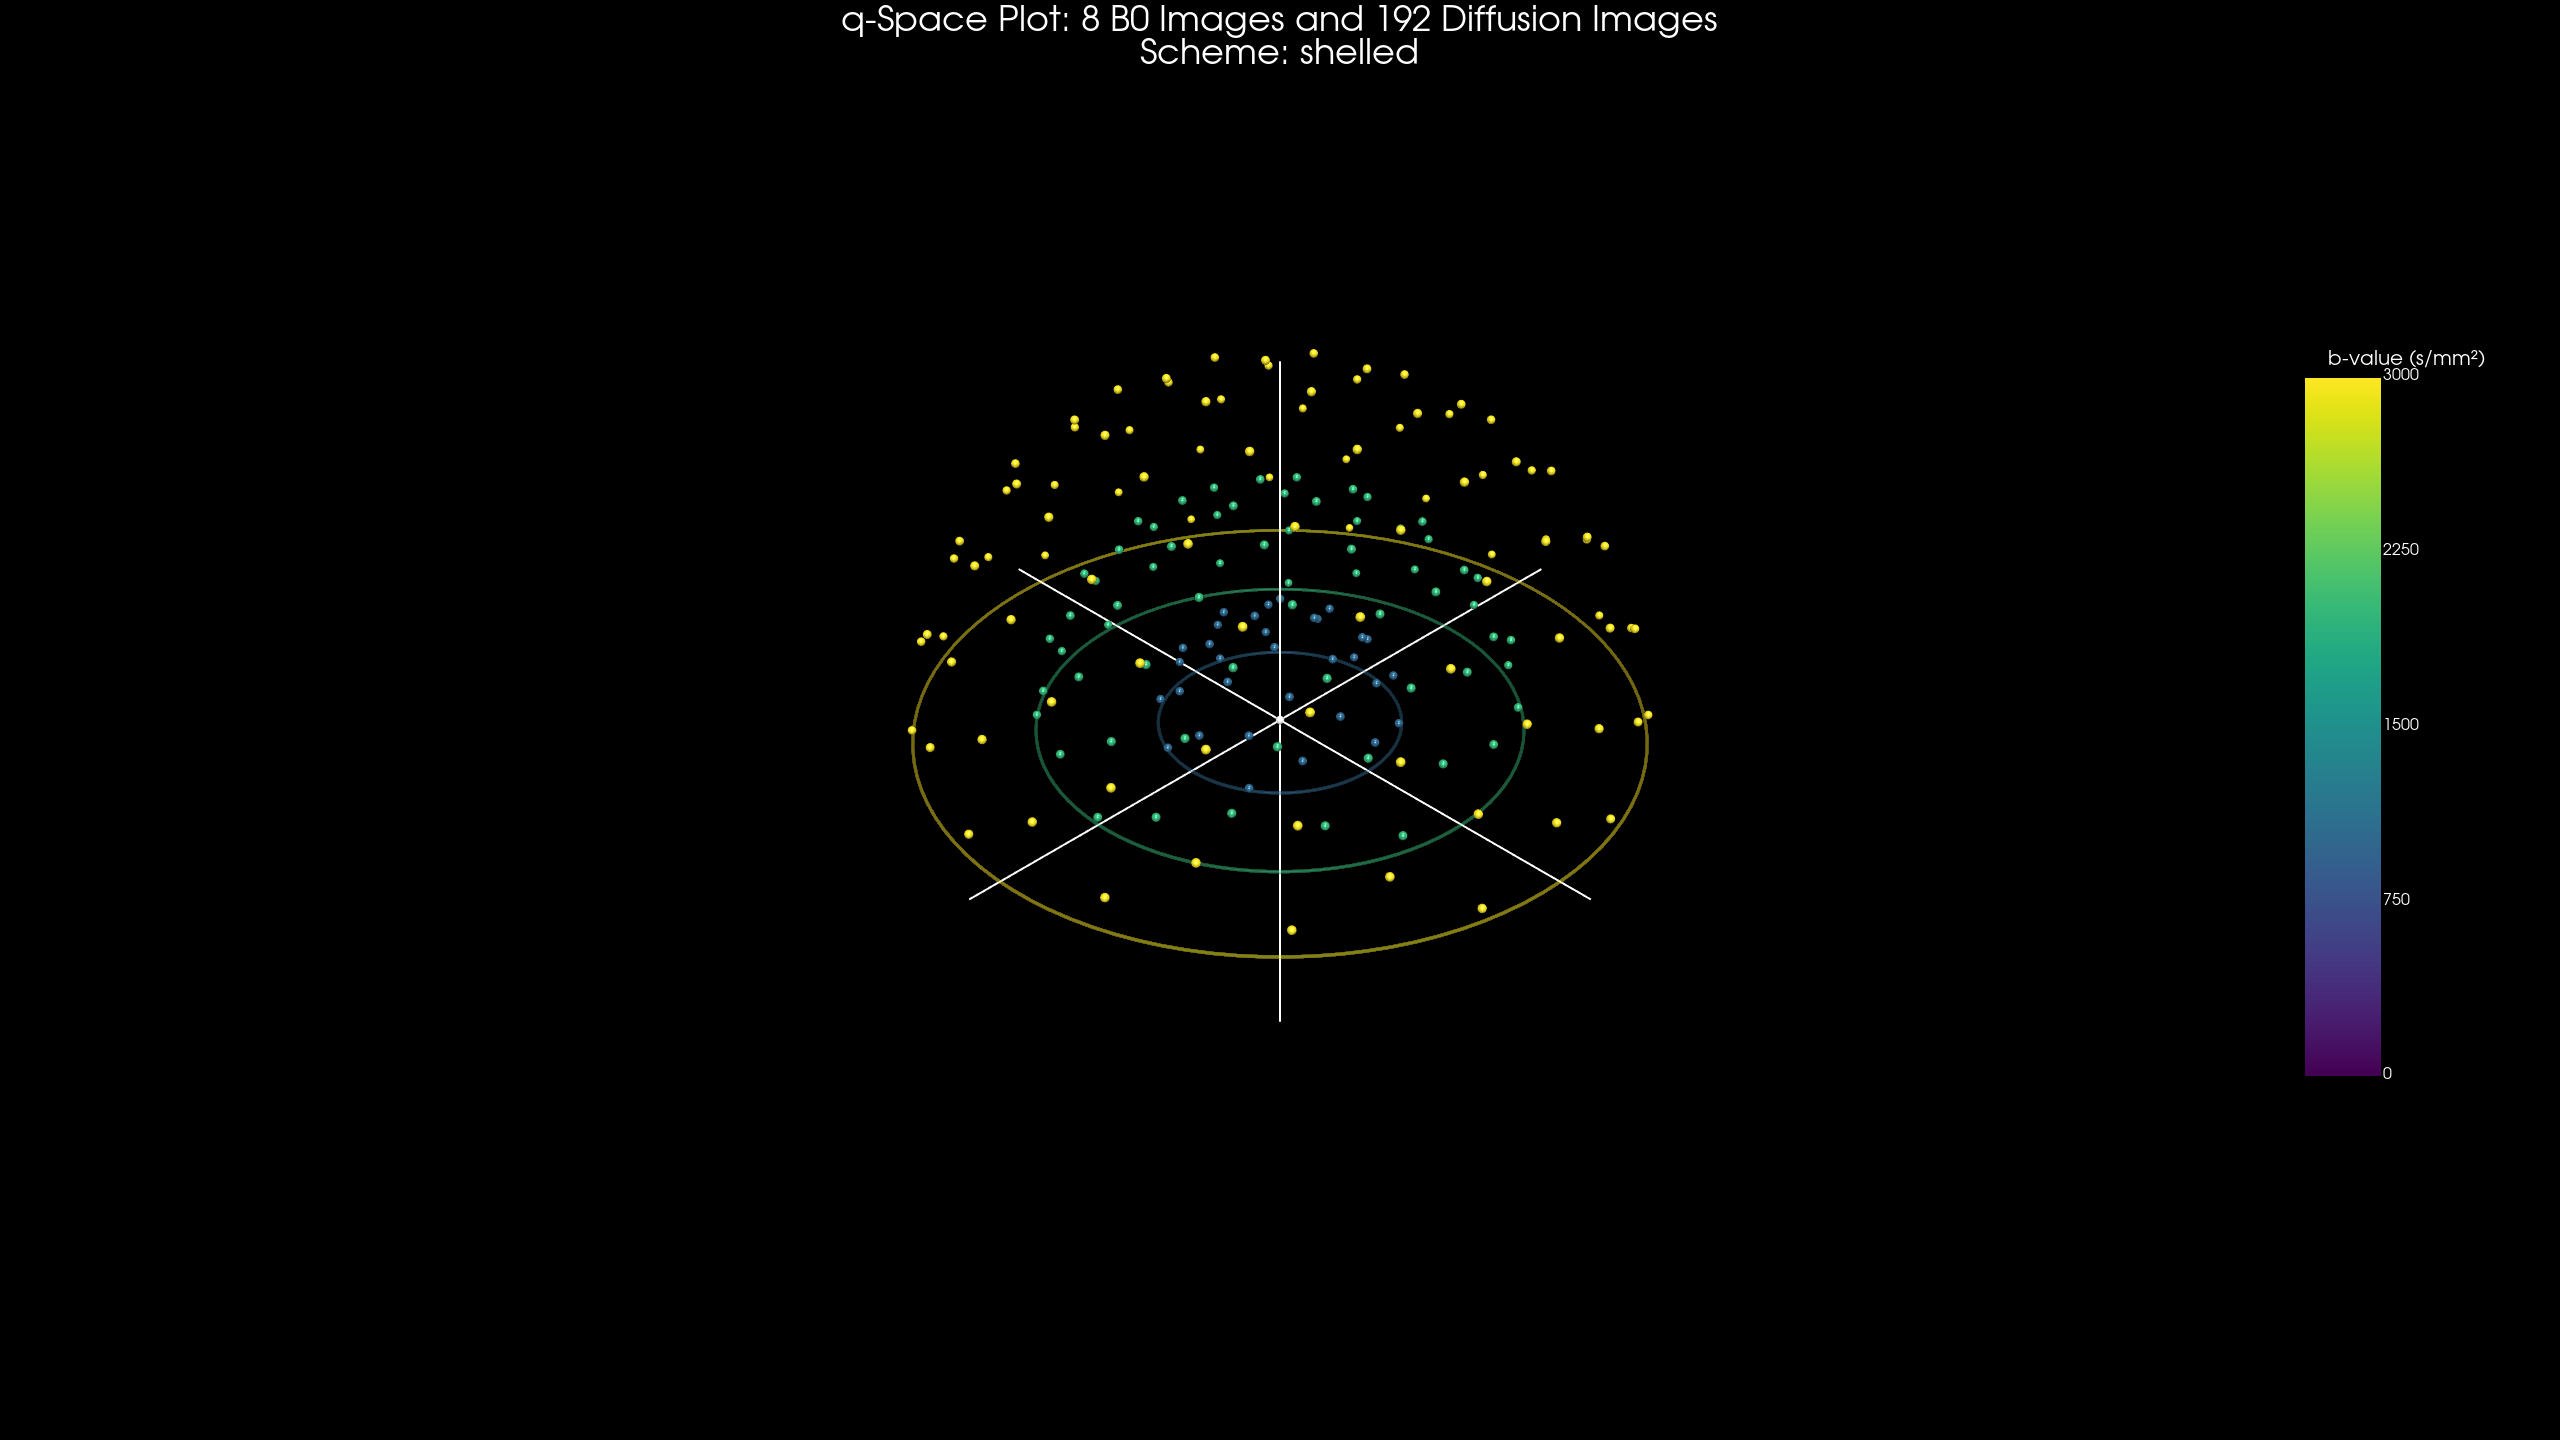

-------------------------------
 
Test 3: Saving a DSI (cartesian) scheme as an interactive HTML file (it can be rotated and zoomed)...
-------------------------------


In [1]:
########################### Testing plot ###########################
import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)
from IPython.display import Image, display

import clabtoolkit.dwitools as cltdwi
import numpy as np
import os

out_dir = "/tmp/dwitools_examples/schemes"
os.makedirs(out_dir, exist_ok=True)

scheme_ss= cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("shelled", shells={1000: 64}, n_b0s=8)
scheme_ms = cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("shelled", shells={1000: 32, 2000: 64, 3000: 96}, n_b0s=8)
scheme_dsi = cltdwi.DiffusionScheme.simulate_dwi_acq_scheme("dsi", bmax=4000,)

# NOTE: Without save_path, plot() opens an interactive PyVista window (or a notebook widget with
#       use_notebook=True). With save_path, the figure is rendered off-screen and saved instead:
#       .html/.htm -> interactive HTML, .svg/.pdf/.eps/.ps/.tex -> vector graphic, others -> screenshot.

print("Test 1: Saving a single-shell scheme as a PNG image (each direction and its opposite)...")
png_file = os.path.join(out_dir, "single_shell.png")
scheme_ss.plot(save_path=png_file)
display(Image(filename=png_file, width=600))
print("-------------------------------")
print(" ")

print("Test 2: Saving a multi-shell scheme with another colormap, without the opposite directions...")
png_file = os.path.join(out_dir, "multi_shell.png")
scheme_ms.plot(
    save_path=png_file, colormap="viridis", show_opposite_dirs=False, sphere_radius=20
)
display(Image(filename=png_file, width=600))
print("-------------------------------")
print(" ")

print("Test 3: Saving a DSI (cartesian) scheme as an interactive HTML file (it can be rotated and zoomed)...")
scheme_dsi.plot(
    toroid_alpha=0.51,
    show_opposite_dirs=False,
    window_size=(800, 500)
)
print("-------------------------------")
